In [2]:
import os
import numpy as np
import scipy.io as sio
import pickle
import matplotlib.pyplot as plt

### Window length distribution

In [3]:
import pickle

with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-FullMovies\Emotion_scores\scores_allMovies_resample.pkl', 'rb') as f:
    scores_dict = pickle.load(f)
# del scores_dict['BV1zW411d7Rb']
with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-FullMovies\Emotion_scores\times_allMovies_resample.pkl', 'rb') as f:
    time_dict= pickle.load(f)
# del time_dict['BV1zW411d7Rb']

print(len(scores_dict.keys()))
print(len(time_dict.keys()))

scores_all = np.zeros((0,6))
n_samples = []

scores_key = list(scores_dict.keys())
count = 0
for key in scores_key:
    print(scores_dict[key].shape)
    scores_all = np.concatenate((scores_all, scores_dict[key]), 0)
    n_samples.append(scores_dict[key].shape[0])
    count += 1
print(scores_all.shape)
n_samples_cum = np.concatenate((np.array([0]), np.cumsum(n_samples)))
print(n_samples_cum[-5:])

102
102
(4565, 6)
(3699, 6)
(4218, 6)
(1158, 6)
(3955, 6)
(3907, 6)
(4714, 6)
(3192, 6)
(2984, 6)
(3800, 6)
(3051, 6)
(3007, 6)
(4277, 6)
(5197, 6)
(3371, 6)
(3058, 6)
(3692, 6)
(3824, 6)
(3642, 6)
(3513, 6)
(6846, 6)
(2616, 6)
(2717, 6)
(3223, 6)
(3500, 6)
(4148, 6)
(3174, 6)
(3960, 6)
(3516, 6)
(3088, 6)
(4303, 6)
(2692, 6)
(4010, 6)
(2179, 6)
(2700, 6)
(4200, 6)
(3530, 6)
(3611, 6)
(3210, 6)
(4031, 6)
(3293, 6)
(4606, 6)
(5233, 6)
(3487, 6)
(4200, 6)
(3405, 6)
(4484, 6)
(3562, 6)
(3987, 6)
(4766, 6)
(3337, 6)
(2703, 6)
(2995, 6)
(2522, 6)
(4044, 6)
(3547, 6)
(3019, 6)
(2789, 6)
(1396, 6)
(3753, 6)
(3557, 6)
(4445, 6)
(5073, 6)
(3361, 6)
(3299, 6)
(3914, 6)
(2651, 6)
(2634, 6)
(3734, 6)
(3296, 6)
(5312, 6)
(4252, 6)
(2729, 6)
(2721, 6)
(3117, 6)
(2910, 6)
(4223, 6)
(2703, 6)
(3214, 6)
(3854, 6)
(3990, 6)
(3631, 6)
(3372, 6)
(2874, 6)
(3032, 6)
(2207, 6)
(3129, 6)
(2081, 6)
(2788, 6)
(2601, 6)
(4910, 6)
(3071, 6)
(1895, 6)
(4002, 6)
(4031, 6)
(3191, 6)
(2957, 6)
(3355, 6)
(2830, 6)
(3

In [4]:
batch_dir = r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-FullMovies\Processed_danmu'
# batch2_dir = r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-film\Processed_danmu\movie_batch2'
files = os.listdir(batch_dir)

time_interval = []
for i in range(102):
    with open(os.path.join(batch_dir, files[i]), 'rb') as f:
        danmu_data = pickle.load(f)
    # key_name = '_'.join(files[i].split('_')[1:-1])
    # print(files[i], danmu_data.keys())
    key_list = list(danmu_data.keys())
    time_range = danmu_data[key_list[1]]
    for j in range(len(time_range)):
        time_interval.append(time_range[j][1] - time_range[j][0])
    print(np.median(time_interval))

0.9169999999999163
0.9429999999999836
0.9359999999996944
0.9469999999992069
0.9400000000005093
0.9420000000000073
0.9484999999999673
0.9579999999998563
0.9630000000000223
0.9720000000002074
0.9589999999998327
0.963000000000001
0.9690000000000509
0.9740000000001601
0.9809999999999945
0.9899999999997817
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
0.9819999999999993
0.9729999999999563
0.9710000000000036
0.9649999999999181
0.9619999999999891
0.9639999999999418
0.9659999999994398
0.9679999999989377
0.9690000000000509
0.9680000000000746
0.9700000000011642
0.9710000000004584
0.9729999999999563
0.9749999999999943
0.9760000000005675
0.9759999999998854
0.9780000000000655
0.9709999999995489
0.9720000000002074
0.9740000000000464
0.974999999999909
0.9760000000001128
0.974999999999909
0.9769999999989523
0.9780000000000655
0.9790000000002692
0.9800000000000182
0.9819999999999709
0.9830000000001746
0.9859999999998763
0.9879999999993743
0.9859999999998763
0.9879999999993743
0.9890000000

In [5]:
time_interval = np.array(time_interval) + 1.
print(np.sum(time_interval <= 3.0) / len(time_interval))

0.7725722435817933


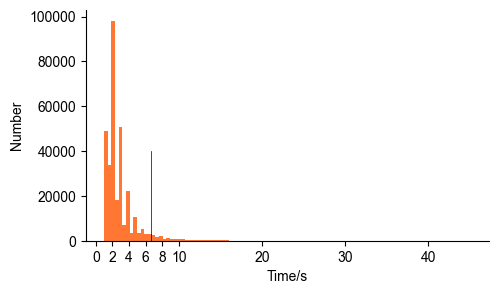

6.607999999999959


In [6]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Arial'
fig, ax = plt.subplots(figsize=(5.2, 3.))
plt.hist(time_interval, bins=100, color='#FF5500', alpha=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel('Time/s')
plt.ylabel('Number')
plt.xticks([0,2,4,6,8,10,20,30,40])
plt.plot([np.percentile(time_interval, 95), np.percentile(time_interval, 95)], [0,40000], linewidth=0.5, color='black')
plt.savefig('figures/time_bin.svg')
plt.show()
# print(np.max(time_interval))
# print(np.sum(time_interval > 10) / len(time_interval))
print(np.percentile(time_interval, 95))

In [7]:
batch_dir = r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-FullMovies\Processed_danmu'
# batch2_dir = r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-film\Processed_danmu\movie_batch2'
files = os.listdir(batch_dir)

time_interval = {}
for i in range(102):
    with open(os.path.join(batch_dir, files[i]), 'rb') as f:
        danmu_data = pickle.load(f)
    # key_name = '_'.join(files[i].split('_')[1:-1])
    # print(files[i], danmu_data.keys())
    key_list = list(danmu_data.keys())
    time_range = danmu_data[key_list[1]]
    tmp = []
    for j in range(len(time_range)):
        time_interval_now = time_range[j][1] - time_range[j][0]
        if np.sum(np.mod(time_interval_now, 1)) == 0:
            tmp.append(time_interval_now + 1)
        else:
            tmp.append(np.round(time_interval_now))
    tmp = np.array(tmp)
    time_interval[files[i]] = tmp
    print(files[i], np.max(tmp))

danmu_5_Centimeters_Per_Second_downsample.pkl 10.0
danmu_A_Little_Thing_Called_Love_downsample.pkl 7.0
danmu_A_Silent_Voice_downsample.pkl 4.0
danmu_Batman_Dark_Knight_downsample.pkl 22.0
danmu_Be_Somebody_downsample.pkl 10.0
danmu_Big_World_Gashapon_downsample.pkl 32.0
danmu_Brotherhood_Of_Blades_downsample.pkl 12.0
danmu_Catch_Me_If_You_Can_downsample.pkl 15.0
danmu_Cj7_downsample.pkl 33.0
danmu_Crazy_Racer_downsample.pkl 12.0
danmu_Date_A_Live_Movie_Mayuri_Judgment_downsample.pkl 7.0
danmu_Deep_Sea_downsample.pkl 20.0
danmu_Detective_Conan_The_Bride_Of_Halloween_downsample.pkl 16.0
danmu_Detective_Conan_The_Phantom_Of_Baker_Street_downsample.pkl 11.0
danmu_Edge_Of_Tomorrow_downsample.pkl 30.0
danmu_Endless_Journey_downsample.pkl 25.0
danmu_Evangelion_1.11_You_Are_(Not)_Alone_downsample.pkl 15.0
danmu_Evangelion_2.22_You_Can_(Not)_Advance_downsample.pkl 11.0
danmu_Evangelion_3.33_You_Can_(Not)_Redo_downsample.pkl 15.0
danmu_Evangelion_Death_And_Rebirth_downsample.pkl 27.0
danm

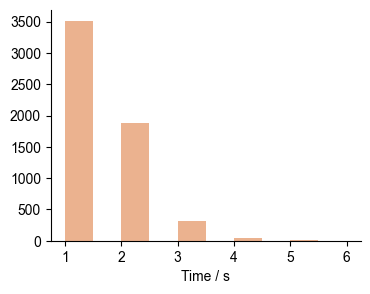

6.0
6.0


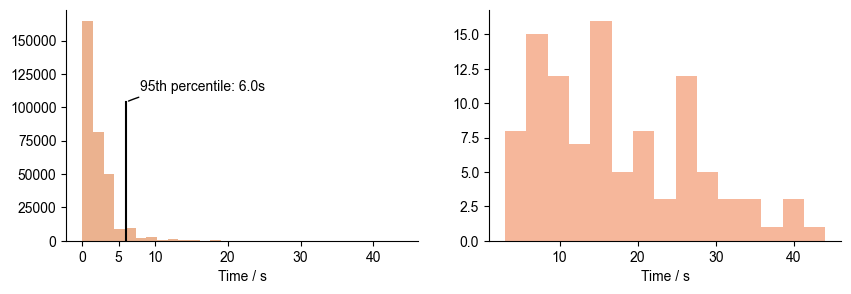

In [8]:
time_interval_list = []
for i in range(102):
    time_interval_list.extend(list(time_interval[files[i]]))
time_interval_max = []
for i in range(102):
    time_interval_max.append(max(time_interval[files[i]]))
fig, ax = plt.subplots(figsize=(4,3))
plt.hist(time_interval['danmu_Forrest_Gump_downsample.pkl'],
         color='#E69F73', alpha=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# plt.title('Window lengths in Forrest Gump')
plt.xlabel('Time / s')
plt.savefig('figures/forrest_time_bin.svg', dpi=300, bbox_inches='tight')
plt.show()
print(np.max(time_interval['danmu_Forrest_Gump_downsample.pkl']))

fig, (ax1, ax2) = plt.subplots(1,2,figsize=(10,3))
plt.subplot(121)
plt.hist(np.array(time_interval_list), bins=30,
         color='#E69F73', alpha=0.8)
print(np.percentile(np.array(time_interval_list), 95))
p95 = np.percentile(time_interval_list, 95)
ax1.plot([p95, p95], [0, ax1.get_ylim()[1]*0.6], color='black', linestyle='-')
ax1.annotate(f'95th percentile: {p95:.1f}s', 
             xy=(p95, ax1.get_ylim()[1]*0.6),  # 箭头指向垂直线顶端
             xytext=(p95+2, ax1.get_ylim()[1]*0.65),  # 文本位置偏右上方
             fontsize=10,
             arrowprops=dict(arrowstyle='-', color='black', 
                           connectionstyle="arc3,rad=0.1"))  # 轻微弯曲的斜线
# plt.title('All intervals')
plt.xlabel('Time / s')
plt.xticks([0,5,10,20,30,40])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
plt.subplot(122)
plt.hist(np.array(time_interval_max), bins=15,
         color='#F4A582', alpha=0.8)
# plt.title('Max intervals within a movie')
plt.xlabel('Time / s')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
plt.savefig('figures/all_time_bin.svg', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
print(np.max(time_interval_list))
print(np.mean(time_interval_max), np.median(time_interval_max))

44.0
17.392156862745097 15.0


danmu_Episode10_downsample.pkl 31.0
danmu_Episode11_downsample.pkl 35.0
danmu_Episode12_downsample.pkl 30.0
danmu_Episode13_downsample.pkl 16.0
danmu_Episode1_downsample.pkl 7.0
danmu_Episode2_downsample.pkl 16.0
danmu_Episode3_downsample.pkl 18.0
danmu_Episode4_downsample.pkl 18.0
danmu_Episode5_downsample.pkl 19.0
danmu_Episode6_downsample.pkl 30.0
danmu_Episode7_downsample.pkl 27.0
danmu_Episode8_downsample.pkl 21.0
danmu_Episode9_downsample.pkl 20.0


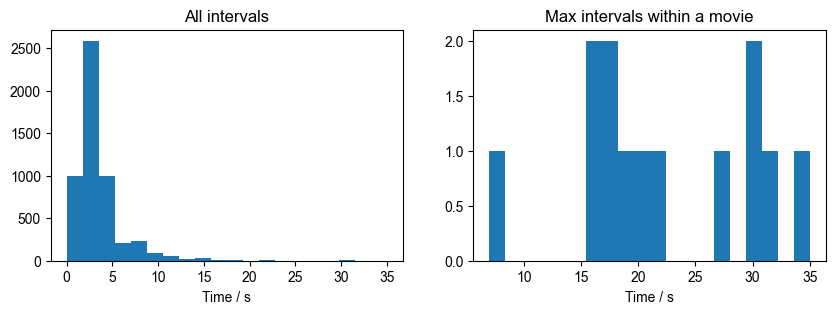

In [10]:
batch_dir = r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-BilingualAnimes\Processed_danmu\Chinese'
# batch2_dir = r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-film\Processed_danmu\movie_batch2'
files = os.listdir(batch_dir)

# time_interval = {}
for i in range(13):
    with open(os.path.join(batch_dir, files[i]), 'rb') as f:
        danmu_data = pickle.load(f)
    # key_name = '_'.join(files[i].split('_')[1:-1])
    # print(files[i], danmu_data.keys())
    key_list = list(danmu_data.keys())
    time_range = danmu_data[key_list[1]]
    tmp = []
    for j in range(len(time_range)):
        tmp.append(np.round(time_range[j][1] - time_range[j][0]))
    tmp = np.array(tmp)
    time_interval[files[i]] = tmp
    print(files[i], np.max(tmp))
    
time_interval_list_chin = []
for i in range(13):
    time_interval_list_chin.extend(list(time_interval[files[i]]))
    time_interval_list.extend(list(time_interval[files[i]]))
time_interval_max_chin = []
for i in range(13):
    time_interval_max_chin.append(max(time_interval[files[i]]))
    time_interval_max.append(max(time_interval[files[i]]))
plt.figure(figsize=(10,3))
plt.subplot(121)
plt.hist(np.array(time_interval_list_chin), bins=20)
plt.title('All intervals')
plt.xlabel('Time / s')
plt.subplot(122)
plt.hist(np.array(time_interval_max_chin), bins=20)
plt.title('Max intervals within a movie')
plt.xlabel('Time / s')
plt.show()

danmu_Uncle_from_Another_World_ep_10_comment_downsample.pkl 14.0
danmu_Uncle_from_Another_World_ep_11_comment_downsample.pkl 12.0
danmu_Uncle_from_Another_World_ep_12_comment_downsample.pkl 11.0
danmu_Uncle_from_Another_World_ep_13_comment_downsample.pkl 15.0
danmu_Uncle_from_Another_World_ep_1_comment_downsample.pkl 7.0
danmu_Uncle_from_Another_World_ep_2_comment_downsample.pkl 10.0
danmu_Uncle_from_Another_World_ep_3_comment_downsample.pkl 12.0
danmu_Uncle_from_Another_World_ep_4_comment_downsample.pkl 10.0
danmu_Uncle_from_Another_World_ep_5_comment_downsample.pkl 12.0
danmu_Uncle_from_Another_World_ep_6_comment_downsample.pkl 15.0
danmu_Uncle_from_Another_World_ep_7_comment_downsample.pkl 14.0
danmu_Uncle_from_Another_World_ep_8_comment_downsample.pkl 14.0
danmu_Uncle_from_Another_World_ep_9_comment_downsample.pkl 16.0


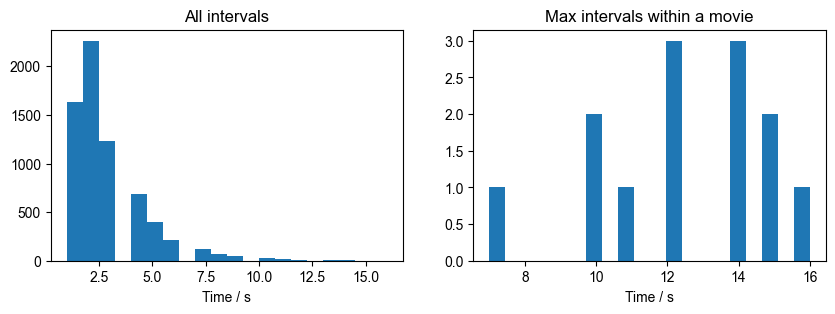

In [11]:
batch_dir = r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-BilingualAnimes\Processed_danmu\Japanese'
# batch2_dir = r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-film\Processed_danmu\movie_batch2'
files = os.listdir(batch_dir)

# time_interval = {}
for i in range(13):
    with open(os.path.join(batch_dir, files[i]), 'rb') as f:
        danmu_data = pickle.load(f)
    # key_name = '_'.join(files[i].split('_')[1:-1])
    # print(files[i], danmu_data.keys())
    key_list = list(danmu_data.keys())
    time_range = danmu_data[key_list[1]]
    tmp = []
    for j in range(len(time_range)):
        tmp.append(time_range[j][1] - time_range[j][0] + 1)
    tmp = np.array(tmp)
    time_interval[files[i]] = tmp
    print(files[i], np.max(tmp))
    
time_interval_list_japa = []
for i in range(13):
    time_interval_list_japa.extend(list(time_interval[files[i]]))
    time_interval_list.extend(list(time_interval[files[i]]))
time_interval_max_japa = []
for i in range(13):
    time_interval_max_japa.append(max(time_interval[files[i]]))
    time_interval_max.append(max(time_interval[files[i]]))
plt.figure(figsize=(10,3))
plt.subplot(121)
plt.hist(np.array(time_interval_list_japa), bins=20)
plt.title('All intervals')
plt.xlabel('Time / s')
plt.subplot(122)
plt.hist(np.array(time_interval_max_japa), bins=20)
plt.title('Max intervals within a movie')
plt.xlabel('Time / s')
plt.show()

Chinese Danmu 95th percentile: 8.00s
Japanese Danmu 95th percentile: 6.00s


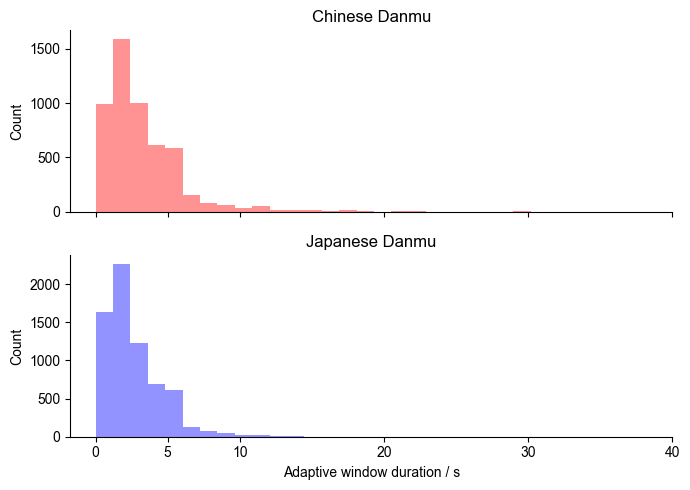

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Convert to numpy arrays and add 1 s, following your original plotting logic
chin_intervals = np.array(time_interval_list_chin)
japa_intervals = np.array(time_interval_list_japa)

# Remove NaN or inf if any
chin_intervals = chin_intervals[np.isfinite(chin_intervals)]
japa_intervals = japa_intervals[np.isfinite(japa_intervals)]

# Use common bins for fair visual comparison
all_intervals = np.concatenate([chin_intervals, japa_intervals])
bins = np.linspace(0, max(all_intervals), 30)

fig, axes = plt.subplots(2, 1, figsize=(7, 5), sharex=True)

plot_info = [
    (axes[0], chin_intervals, 'Chinese Danmu', '#ff6666'),
    (axes[1], japa_intervals, 'Japanese Danmu', '#6666ff')
]

for ax, data, title, color in plot_info:
    ax.hist(data, bins=bins, color=color, alpha=0.7)

    p95 = np.percentile(data, 95)
    print(f'{title} 95th percentile: {p95:.2f}s')

    # ymax = ax.get_ylim()[1]
    # ax.plot(
    #     [p95, p95],
    #     [0, ymax * 0.6],
    #     color='black',
    #     linestyle='-',
    #     linewidth=1.2
    # )

    # ax.annotate(
    #     f'95th percentile: {p95:.1f}s',
    #     xy=(p95, ymax * 0.6),
    #     xytext=(p95 + 2, ymax * 0.68),
    #     fontsize=10,
    #     arrowprops=dict(
    #         arrowstyle='-',
    #         color='black',
    #         connectionstyle="arc3,rad=0.1"
    #     )
    # )

    ax.set_title(title)
    ax.set_ylabel('Count')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[1].set_xlabel('Adaptive window duration / s')
axes[1].set_xticks([0, 5, 10, 20, 30, 40])

plt.tight_layout()
plt.savefig('figures/danmu_bilingual.jpg')
plt.show()

In [14]:
print(np.median(chin_intervals))
print(np.median(japa_intervals))

3.0
2.0


6.0
6.0


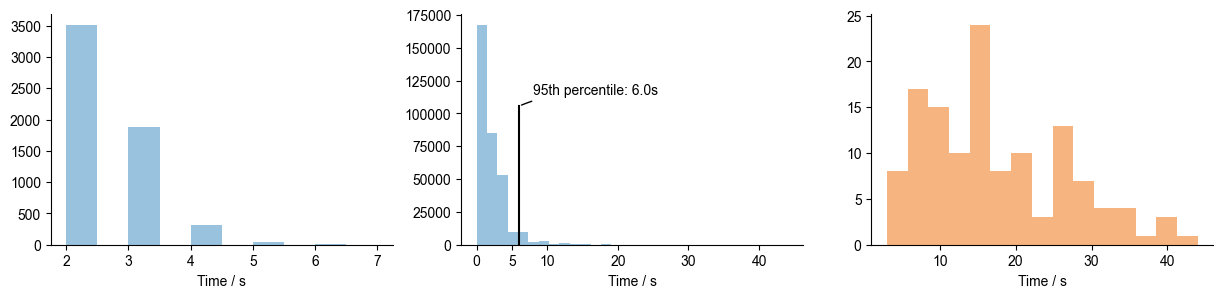

In [15]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3,figsize=(15,3))

plt.subplot(131)
plt.hist(time_interval['danmu_Forrest_Gump_downsample.pkl']+1,
         color='#7FB3D5', alpha=0.8)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
# plt.title('Window lengths in Forrest Gump')
plt.xlabel('Time / s')
# plt.savefig('figures/forrest_time_bin.svg', dpi=300, bbox_inches='tight')
print(np.max(time_interval['danmu_Forrest_Gump_downsample.pkl']))

plt.subplot(132)
plt.hist(np.array(time_interval_list), bins=30,
         color='#7FB3D5', alpha=0.8)
print(np.percentile(np.array(time_interval_list), 95))
p95 = np.percentile(time_interval_list, 95)
ax2.plot([p95, p95], [0, ax2.get_ylim()[1]*0.6], color='black', linestyle='-')
ax2.annotate(f'95th percentile: {p95:.1f}s', 
             xy=(p95, ax2.get_ylim()[1]*0.6),  # 箭头指向垂直线顶端
             xytext=(p95+2, ax2.get_ylim()[1]*0.65),  # 文本位置偏右上方
             fontsize=10,
             arrowprops=dict(arrowstyle='-', color='black', 
                           connectionstyle="arc3,rad=0.1"))  # 轻微弯曲的斜线
# plt.title('All intervals')
plt.xlabel('Time / s')
plt.xticks([0,5,10,20,30,40])
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.subplot(133)
plt.hist(np.array(time_interval_max), bins=15,
         color='#F4A261', alpha=0.8)
# plt.title('Max intervals within a movie')
plt.xlabel('Time / s')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
plt.savefig('figures/all_time_bin_concat.svg', dpi=300, bbox_inches='tight')
plt.show()